In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from groupy import * 

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
def max_filter(templates, X_orbits):
    '''
    X_orbits kxdxn data array 
    templates txd matrix each row is a template
    
    returns max-filter augmented data (torch tensor) 
    '''
    inner_products = result = torch.einsum('td,kdn->ktn', templates, X_orbits)
    maxes, argmaxes = torch.max(inner_products, axis=0)
    return maxes

def squared_lipschitz(squared_distance, fX):
    '''
    Takes in a squared distance matrix in dQ and fX (target_dim x n) array f(X) in the new feature space
    Computes Lipschitz bounds 
    '''
    n = len(squared_distance)
    # Make a list of all the observed expansion factors
    expansions = torch.zeros(round((n*(n-1))/2))
    for i in range(n):
        for j in range(i):
            codomain_distance_squared = ((fX[:, i]-fX[:, j])**2).sum()
            expansion = codomain_distance_squared/squared_distance[i,j]
            expansions[round(i*(i-1)/2)+j] = expansion
    beta_squared = torch.max(expansions)
    alpha_squared = torch.min(expansions)
    return alpha_squared, beta_squared

# Set up data generation and model training parameters

In [3]:
#Create a random test set n pts in d dim
n = 100
d = 4
# number of templates in max filter
t = 3*d
# currently maintain dimensionality given by max filtering
target_dim = t
G = GPU_GroupAction(pmId, d, device=device)

X_test = torch.normal(0, 1, size=(d, n), device=device)
X_test_orbits = G.get_orbits(X_test)
D_test = G.dist_matrix(X_test)

n_trials = 1 #The number of times we will train a new model from scratch
n_epochs = 1 #The number of training epochs for each model
grad_steps_per_epoch = 10 #The number of gradient descent iterations in each training epoch

all_test_distortions = []
all_trained_templates = []
all_trained_Ls = []

# Training Block

In [ ]:
for trial in range(n_trials):
    test_distortions = []

    # max filter template layer
    templates = torch.normal(0, 1, (t, d),requires_grad=True, device=device)
    # linear layer
    L = torch.normal(0,1,(target_dim, t),requires_grad=True, device=device)

    optimizer = torch.optim.Adam([L, templates], lr=1e-2)

    for epoch in range(n_epochs):
        for step in range(grad_steps_per_epoch):
            optimizer.zero_grad()

            # Sample training batch
            X =  torch.normal(0, 1, (d, n), device=device)
            D = G.dist_matrix(X)           # Tensor (n, n)
            X_orbits = G.get_orbits(X)     # Tensor (k, d, n)

            # Forward pass
            norm_templates = F.normalize(templates, dim=1)
            filter_features = max_filter(norm_templates, X_orbits)
            features = L @ filter_features

            alpha_sq, beta_sq = squared_lipschitz(D, features)
            loss = beta_sq / alpha_sq

            loss.backward()
            optimizer.step()
            print(f"Gradient step {step}", end='\r')

        # Test each epoch
        with torch.no_grad():
            norm_templates = F.normalize(templates, dim=1)
            test_features = max_filter(norm_templates, X_test_orbits)
            test_features = L @ test_features
            alpha_test_sq, beta_test_sq = squared_lipschitz(D_test, test_features)
            distortion_test = (beta_test_sq / alpha_test_sq).item()

            print(f"Trial {trial+1}, Epoch {epoch+1} — Test Distortion²: {distortion_test:.4f}")
            test_distortions.append(distortion_test)

    all_test_distortions.append(test_distortions)
    all_trained_templates.append(norm_templates.detach().cpu().numpy())
    all_trained_Ls.append(L.detach().cpu().numpy())

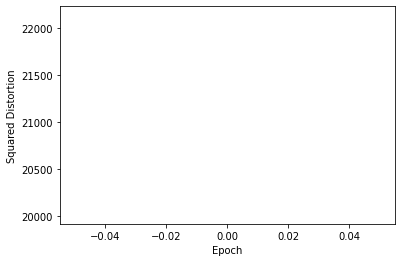

In [68]:
for distortion_function in all_test_distortions:
    plt.plot(distortion_function, alpha=0.3, c='blue')
plt.xlabel("Epoch")
plt.ylabel("Squared Distortion")
plt.show()